****Problem Statement****


Adidas, as a global sportswear brand, generates sales across multiple regions, retailers, and sales channels. However, without structured analysis, it is difficult to identify which regions, products, and retailers drive the most revenue and profit, and how different sales methods (online, offline, distributor) impact performance.


This project aims to perform Exploratory Data Analysis (EDA) on Adidas sales data to uncover trends, measure profitability, and highlight actionable insights that can guide business decisions on product focus, regional strategies, and channel optimization.

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [87]:
df=pd.read_excel("Adidas Sales Data.xlsx")
df.head()

,Retailer,Retailer ID,Region,State,City,Gender Type,Product Category,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,Transaction Date
0,Foot Locker,1185732,Northeast,Pennsylvania,Philadelphia,Men,Apparel,55,125,68750,24062.5,0.35,Outlet,2021-10-26
1,Foot Locker,1185732,Northeast,Pennsylvania,Philadelphia,Women,Apparel,45,225,101250,30375.0,0.30,Outlet,2021-10-27
2,Foot Locker,1185732,Northeast,Pennsylvania,Philadelphia,Men,Street Footwear,45,475,213750,117562.5,0.55,Outlet,2021-10-28
3,Foot Locker,1185732,Northeast,Pennsylvania,Philadelphia,Men,Athletic Footwear,45,125,56250,19687.5,0.35,Outlet,2021-10-29
4,Foot Locker,1185732,Northeast,Pennsylvania,Philadelphia,Women,Street Footwear,35,175,61250,24500.0,0.40,Outlet,2021-10-30


In [88]:
df.shape

(9648, 14)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Region            9648 non-null   object        
 3   State             9648 non-null   object        
 4   City              9648 non-null   object        
 5   Gender Type       9648 non-null   object        
 6   Product Category  9648 non-null   object        
 7   Price per Unit    9648 non-null   int64         
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   int64         
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
 13  Transaction Date  9648 non-null   datetime64[ns]
dtypes: datetime64[ns](1), fl

In [90]:
df.columns

Index(['Retailer', 'Retailer ID', 'Region', 'State', 'City', 'Gender Type',
       'Product Category', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method',
       'Transaction Date'],
      dtype='object')

In [91]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Retailer ID,9648.0,1173849.72357,1128299.0,1185732.0,1185732.0,1185732.0,1197831.0,26360.377309
Price per Unit,9648.0,45.216625,7.0,35.0,45.0,55.0,110.0,14.705397
Units Sold,9648.0,256.930037,0.0,106.0,176.0,350.0,1275.0,214.25203
Total Sales,9648.0,93273.4375,0.0,4254.5,9576.0,150000.0,825000.0,141916.016727
Operating Profit,9648.0,34425.244761,0.0,1921.7525,4371.42,52062.5,390000.0,54193.113713
Operating Margin,9648.0,0.422991,0.1,0.35,0.41,0.49,0.8,0.097197
Transaction Date,9648,2021-05-10 15:20:44.776119552,2020-01-01 00:00:00,2021-02-17 00:00:00,2021-06-04 00:00:00,2021-09-16 00:00:00,2021-12-31 00:00:00,NaN


In [92]:
df.isnull().sum()

Retailer            0
Retailer ID         0
Region              0
State               0
City                0
Gender Type         0
Product Category    0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
Transaction Date    0
dtype: int64

In [93]:
df.duplicated().sum()

0

In [94]:
df.nunique().sum

<bound method Series.sum of Retailer               6
Retailer ID            4
Region                 5
State                 50
City                  52
Gender Type            2
Product Category       3
Price per Unit        94
Units Sold           361
Total Sales         3138
Operating Profit    5618
Operating Margin      66
Sales Method           3
Transaction Date     724
dtype: int64>

In [95]:
#adding new column "Product" which includes (Product Category + Gender Type)
df['Product'] = df['Gender Type'] + df['Product Category']
df["Product"]

0                   MenApparel
1                 WomenApparel
2           MenStreet Footwear
3         MenAthletic Footwear
4         WomenStreet Footwear
                 ...          
9643              WomenApparel
9644        MenStreet Footwear
9645      MenAthletic Footwear
9646      WomenStreet Footwear
9647    WomenAthletic Footwear
Name: Product, Length: 9648, dtype: object

***KPI's***

In [96]:
#Total Revenue Generated
print("Total Revenue : $",df['Total Sales'].sum())

Total Revenue : $ 899902125


In [97]:

#Total Profit
print("Total Profit: $" ,df['Operating Profit'].sum())

Total Profit: $ 332134761.45000005


In [98]:
#Total Transactions
print("Total Transactions : ",df['Transaction Date'].value_counts().sum())

Total Transactions :  9648


In [99]:
#Total Quantity Purchased
print("Total Quantity Purchased : ",df['Units Sold'].sum())

Total Quantity Purchased :  2478861


In [100]:
#Average Profit Margin
print(f"Average Profit Margin:, {df['Operating Margin'].mean()*100:.2f}%")
     

Average Profit Margin:, 42.30%


In [101]:
#total retailer
retailers=df["Retailer ID"].count()
print("Total Retailers are",retailers)

Total Retailers are 9648


In [102]:
#Total product sold
product_sold=df["Units Sold"].sum()
print("Total number of product sold is :",product_sold)

Total number of product sold is : 2478861


In [103]:
#total states were business were expanded
Numbers_of_States=df["State"].nunique()
print("The Business were expanded in",Numbers_of_States,"States")

The Business were expanded in 50 States


In [104]:
#total cities were business were expanded
Numbers_of_States=df["City"].nunique()
print("The Business were expanded in",Numbers_of_States,"Cities")

The Business were expanded in 52 Cities


In [105]:
#Average product sold
Average_products_sold=df.groupby("Product")["Units Sold"].mean().round(2)
Average_products_sold

Product
MenApparel                190.96
MenAthletic Footwear      270.51
MenStreet Footwear        368.52
WomenApparel              269.79
WomenAthletic Footwear    197.53
WomenStreet Footwear      243.95
Name: Units Sold, dtype: float64

In [106]:
#Revenue Generated by products
Revenue_by_products=df.groupby("Product")["Total Sales"].sum()
Revenue_by_products

Product
MenApparel                123728632
MenAthletic Footwear      153673680
MenStreet Footwear        208826244
WomenApparel              179038860
WomenAthletic Footwear    106631896
WomenStreet Footwear      128002813
Name: Total Sales, dtype: int64

***Sales Analysis***

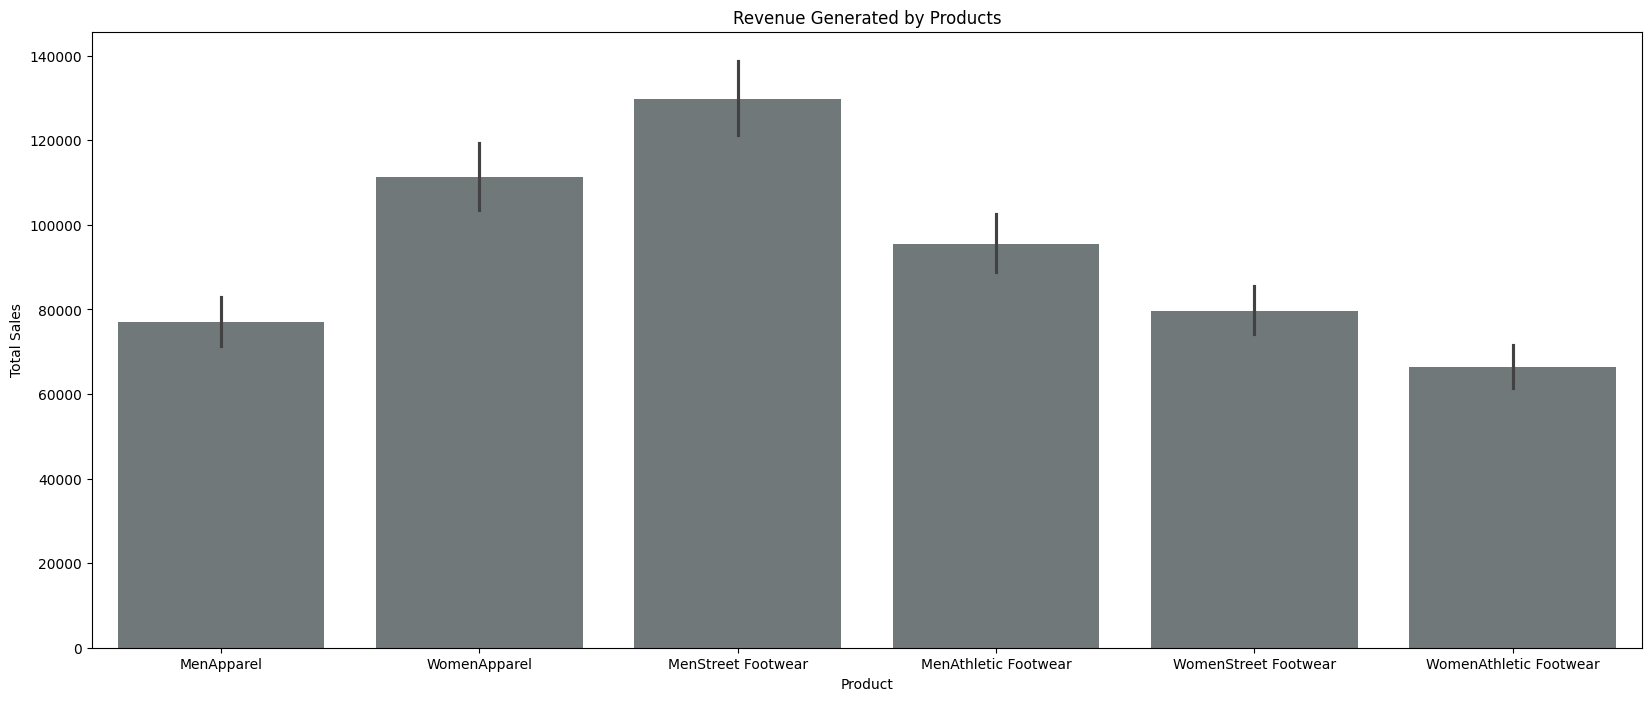

In [107]:
#Visualizing in total Sales by Product
plt.figure(figsize=(20,8))
sns.barplot(x=df["Product"],y=df["Total Sales"],color="#6F797A")
plt.title('Revenue Generated by Products')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.show()

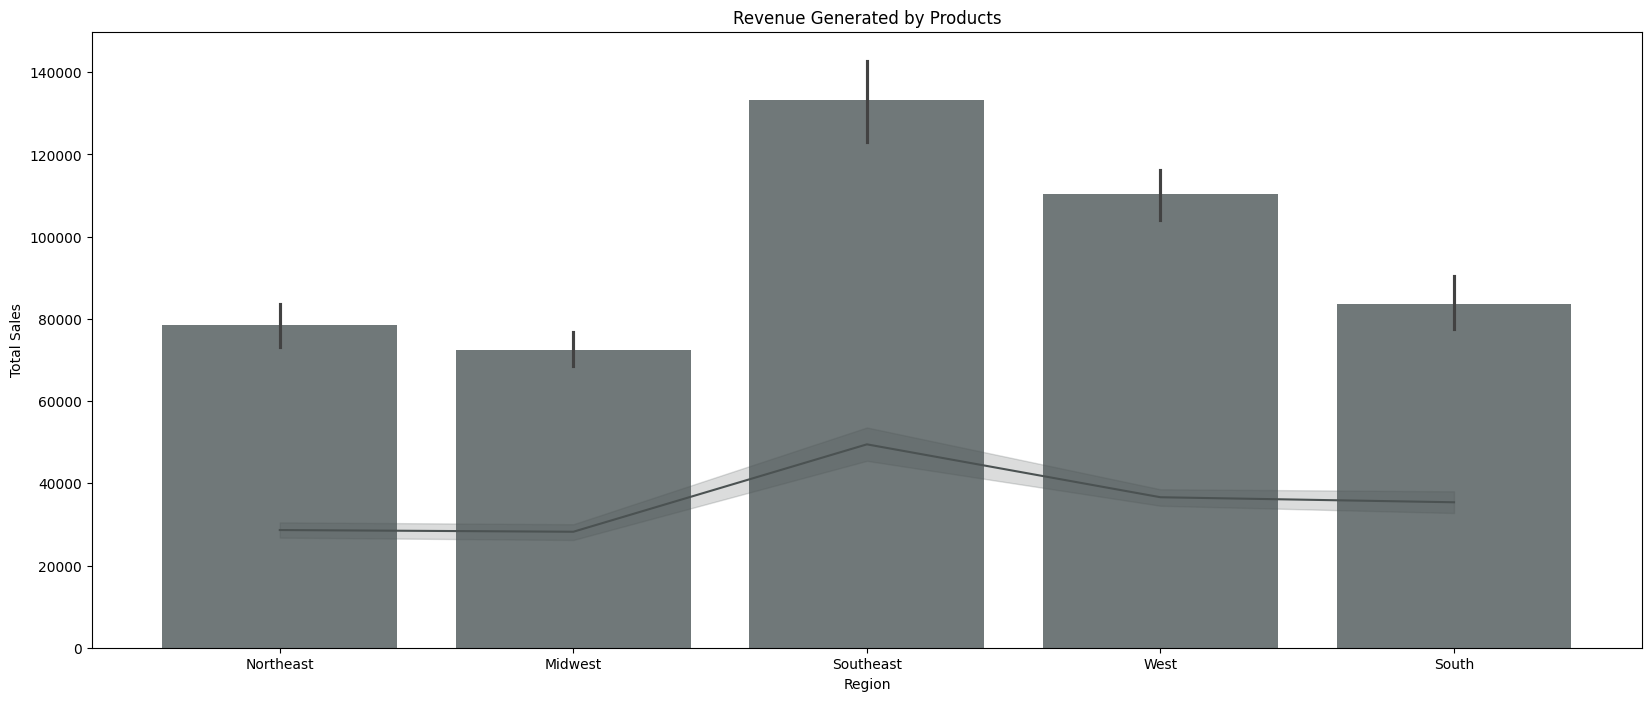

In [108]:
#Visualizing in Sales per region and operational profit 
plt.figure(figsize=(20,8))
sns.barplot(x=df["Region"],y=df["Total Sales"],color="#6F797A")
plt.title('Revenue Generated by Products')
plt.xlabel('Region')
plt.ylabel('Total Sales')
sns.lineplot(x=df["Region"],y=df["Operating Profit"],color="#4B5252")
plt.show()

In [109]:
#adding year-month column for timeline analysis
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])
df['Year-Month'] = df["Transaction Date"].dt.strftime('%Y-%m')
df['Year-Month']

0       2021-10
1       2021-10
2       2021-10
3       2021-10
4       2021-10
         ...   
9643    2020-03
9644    2020-03
9645    2020-03
9646    2020-03
9647    2020-03
Name: Year-Month, Length: 9648, dtype: object

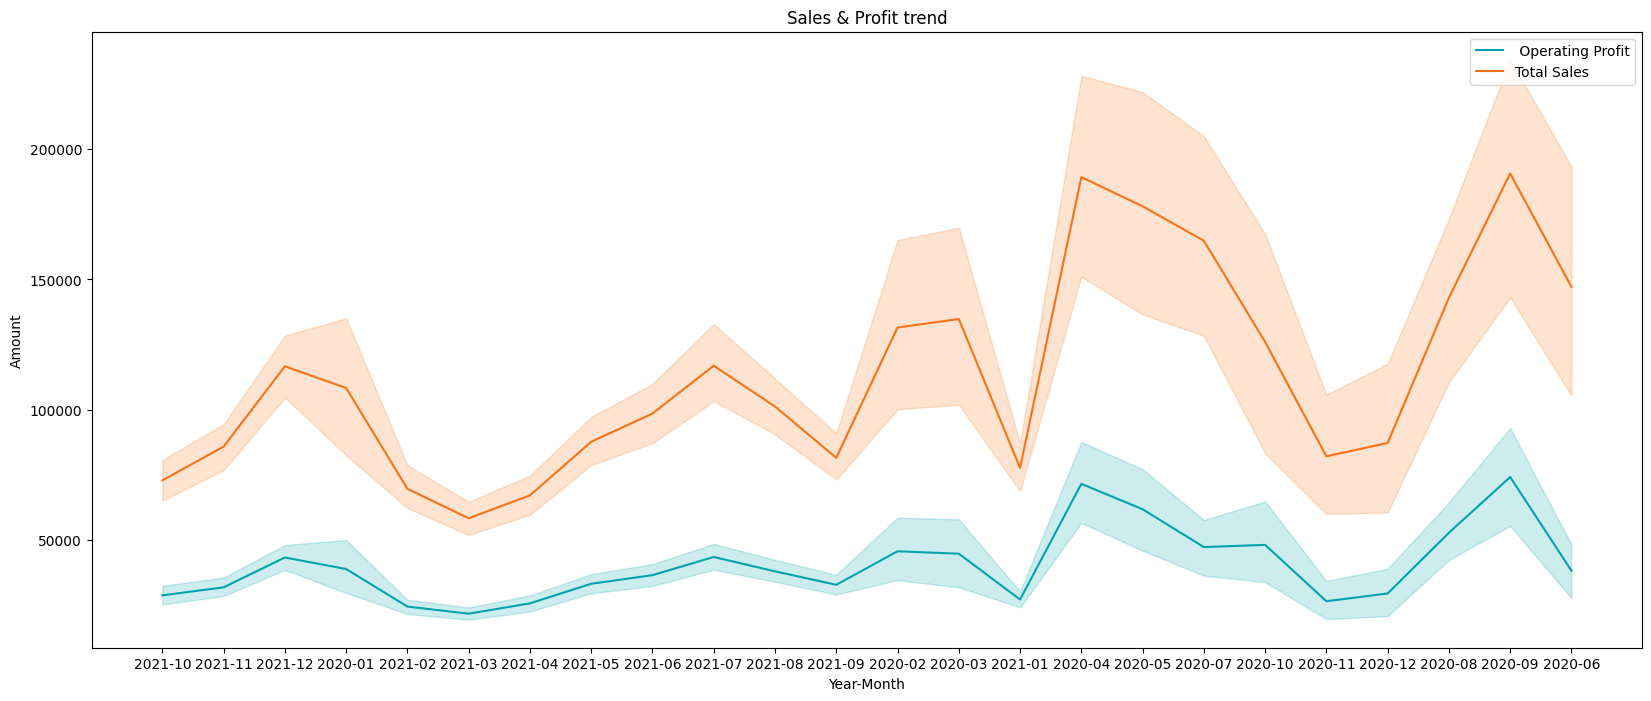

In [110]:
#Sales & Profit trend over the time
plt.figure(figsize=(20,8))
sns.lineplot(x=df['Year-Month'],y=df["Operating Profit"],label=' Operating Profit',color='#02A2AD')
sns.lineplot(x=df["Year-Month"],y=df["Total Sales"],label='Total Sales',color="#F97316")
plt.title('Sales & Profit trend')
plt.xlabel('Year-Month')
plt.ylabel('Amount')
plt.legend()
plt.show()


In [111]:
df['Product Category'].unique()

array(['Apparel', 'Street Footwear', 'Athletic Footwear'], dtype=object)

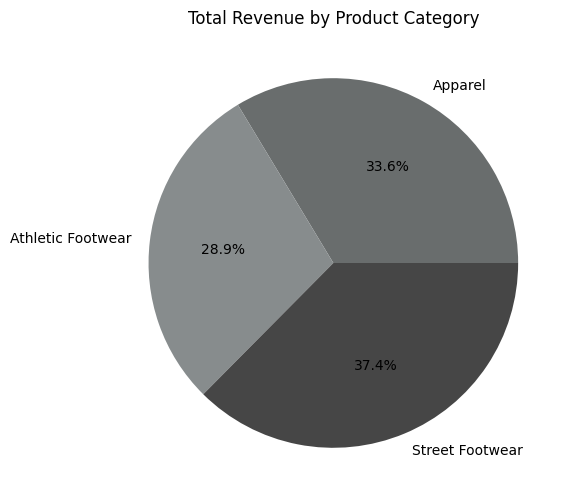

In [112]:
# Revenue generated by product category
plt.figure(figsize=(10, 6))
category_sales = df.groupby("Product Category")["Total Sales"].sum()
colours = ["#696D6D", "#878C8D", "#464646"]
plt.pie(category_sales, labels=category_sales.index, colors=colours, autopct="%1.1f%%")
plt.title("Total Revenue by Product Category")
plt.show()


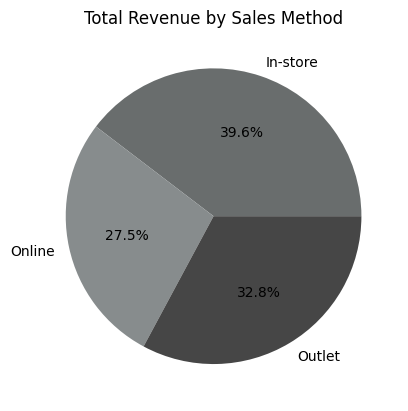

In [113]:
#sales by outlet types
outlet=df.groupby("Sales Method")["Total Sales"].sum().reset_index()
colors = ["#696D6D", "#878C8D", "#464646"]
plt.pie(outlet["Total Sales"],labels=outlet["Sales Method"],colors=colors,autopct='%1.1f%%')
plt.title('Total Revenue by Sales Method')
plt.show()

In [114]:
#regionwise sales 
regions=df.groupby('Region')['Total Sales'].sum().sort_index(ascending=False)
print(regions)

Region
West         269943182
Southeast    163171236
South        144663181
Northeast    186324067
Midwest      135800459
Name: Total Sales, dtype: int64


Text(0.5, 1.0, 'Regionwise Sales')

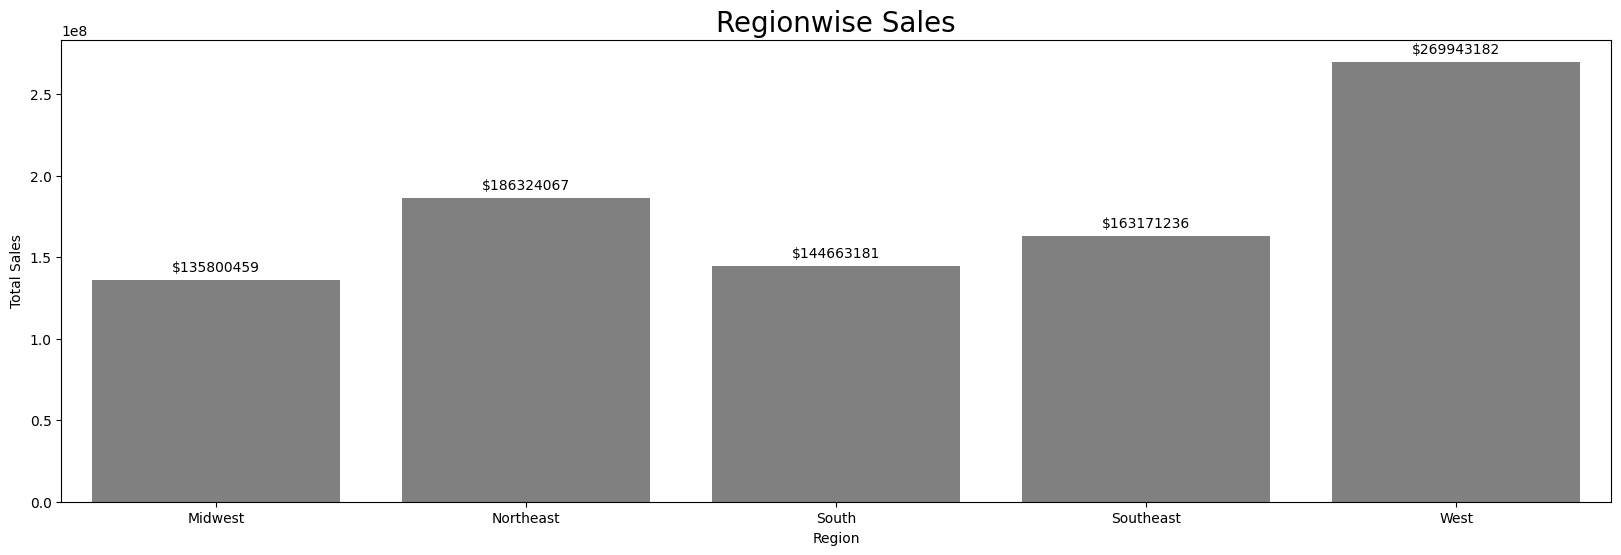

In [115]:
#regionwise sales visuals

plt.figure(figsize=(20,6))
sales=df.groupby('Region')['Total Sales'].sum().reset_index()
ax=sns.barplot(data=sales,x='Region', y='Total Sales',color="grey")
ax.bar_label(ax.containers[0], fmt='$%.0f',padding=4)
plt.title("Regionwise Sales",fontsize=20)

Text(0.5, 1.0, 'Regionwise Operating Profit')

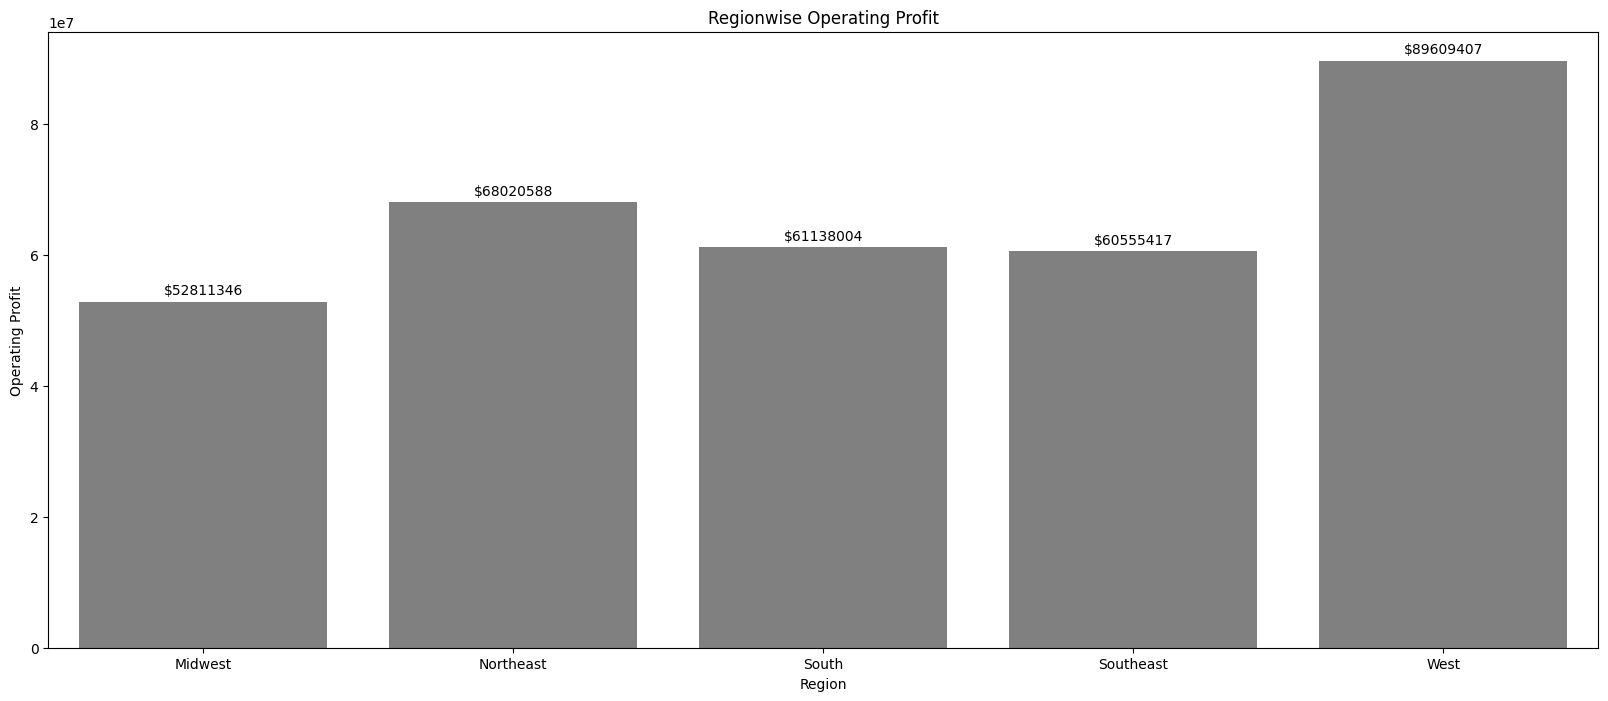

In [116]:
#Regionwise Operating Profit 
profit=df.groupby('Region')['Operating Profit'].sum().reset_index()

plt.figure(figsize=(20,8))
ax=sns.barplot(data=profit,x='Region', y='Operating Profit', color='grey')
ax.bar_label(ax.containers[0], fmt='$%.0f', padding=3)
plt.title("Regionwise Operating Profit")


Text(0.5, 1.0, 'Citywise Operating Profit')

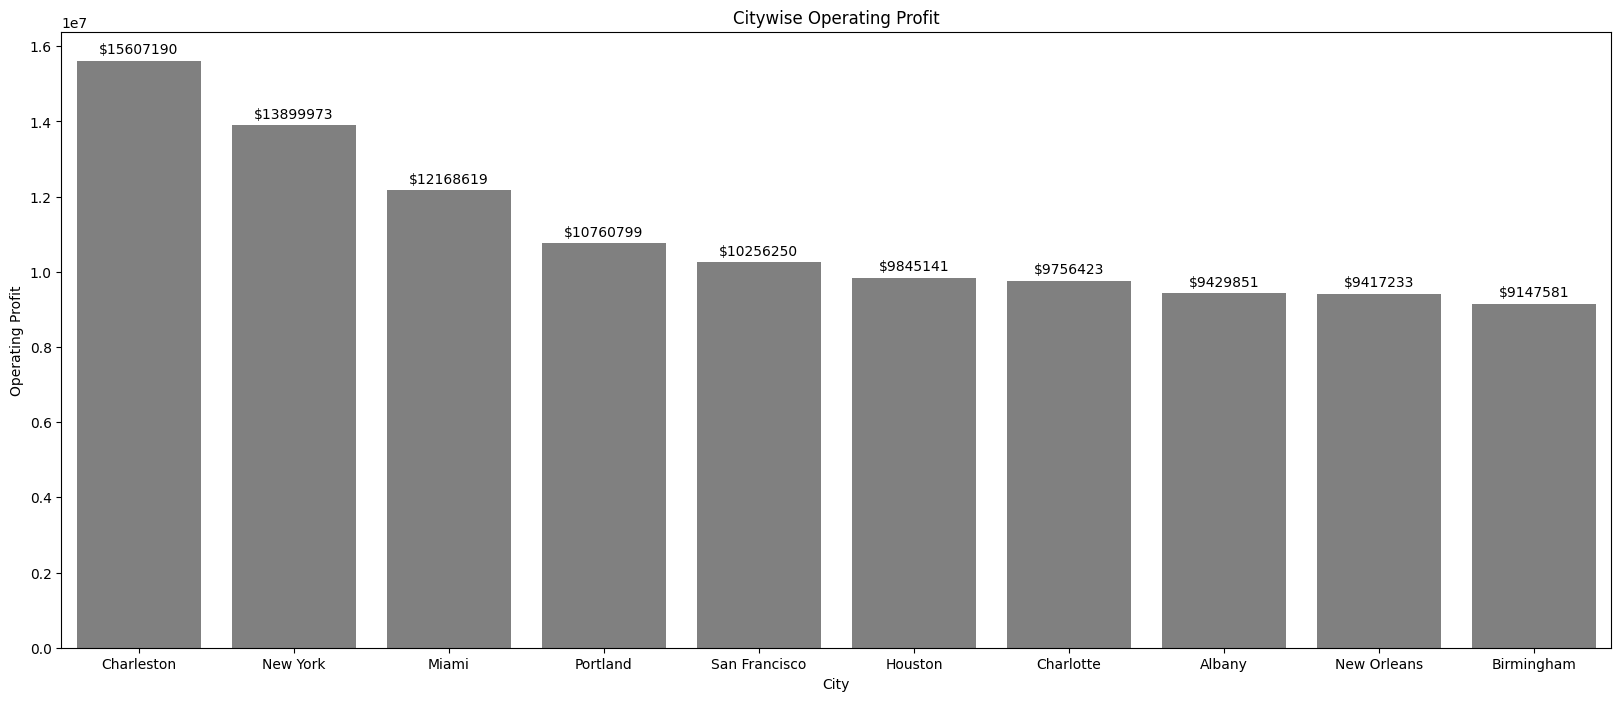

In [117]:
#top 10 citywise operating sales
profit=df.groupby('City')['Operating Profit'].sum().nlargest(10).reset_index()

plt.figure(figsize=(20,8))
ax=sns.barplot(data=profit,x='City', y='Operating Profit', color='grey')
ax.bar_label(ax.containers[0], fmt='$%.0f', padding=3)
plt.title("Citywise Operating Profit")

Text(0.5, 1.0, 'Statewise Operating Profit')

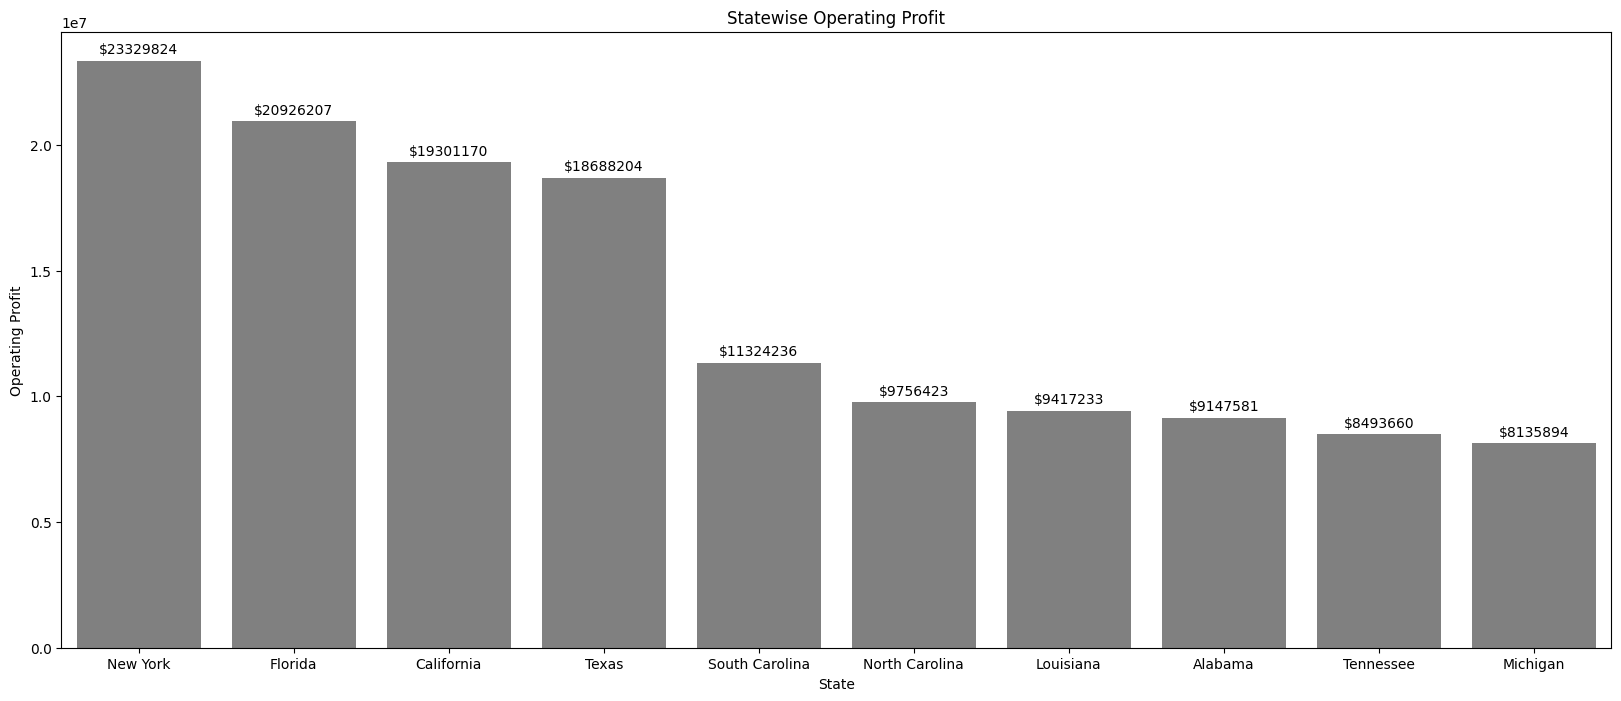

In [118]:
##top 10 statewise operating sales
profit=df.groupby('State')['Operating Profit'].sum().nlargest(10).reset_index()

plt.figure(figsize=(20,8))
ax=sns.barplot(data=profit,x='State', y='Operating Profit', color='grey')
ax.bar_label(ax.containers[0], fmt='$%.0f', padding=3)
plt.title("Statewise Operating Profit")

In [119]:
#Highest sales in the region 
max_sales=df.groupby("Region")["Total Sales"].max().nlargest(1)
print(max_sales)

Region
South    825000
Name: Total Sales, dtype: int64


In [120]:
#Highest sales in the city
max_sales=df.groupby("City")["Total Sales"].max().nlargest(1)
print(max_sales)

City
New Orleans    825000
Name: Total Sales, dtype: int64


In [121]:
##Highest sales in the state 
max_sales=df.groupby("State")["Total Sales"].max().nlargest(1)
print(max_sales)

State
Florida    825000
Name: Total Sales, dtype: int64


Text(0.5, 1.0, 'Citywise Total Sales')

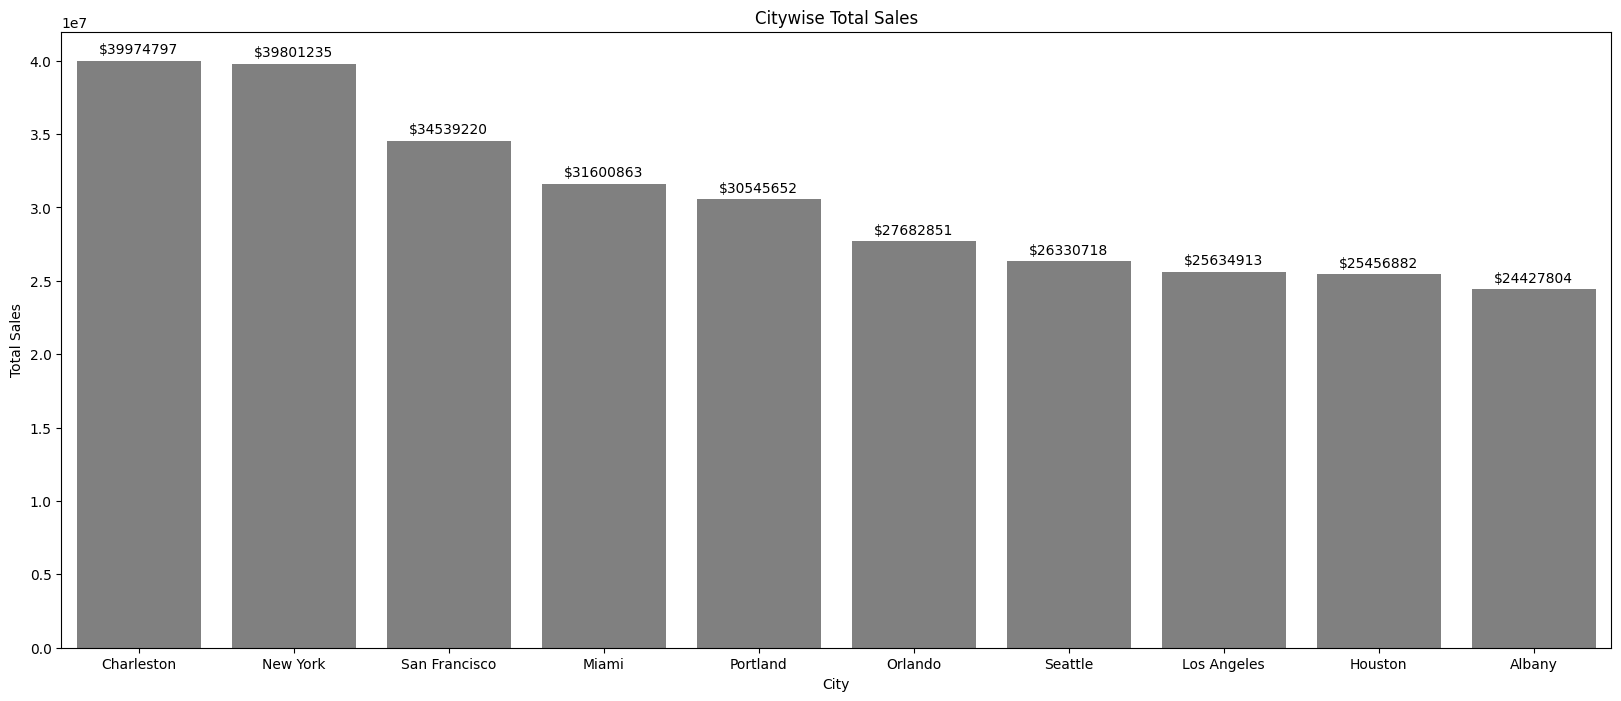

In [122]:
#Top 10 cities by revenue
profit=df.groupby('City')['Total Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(20,8))
ax=sns.barplot(data=profit,x='City', y='Total Sales', color='grey')
ax.bar_label(ax.containers[0], fmt='$%.0f', padding=3)
plt.title("Citywise Total Sales")

*Product Analysis*

Text(0.5, 1.0, 'Top performaing product')

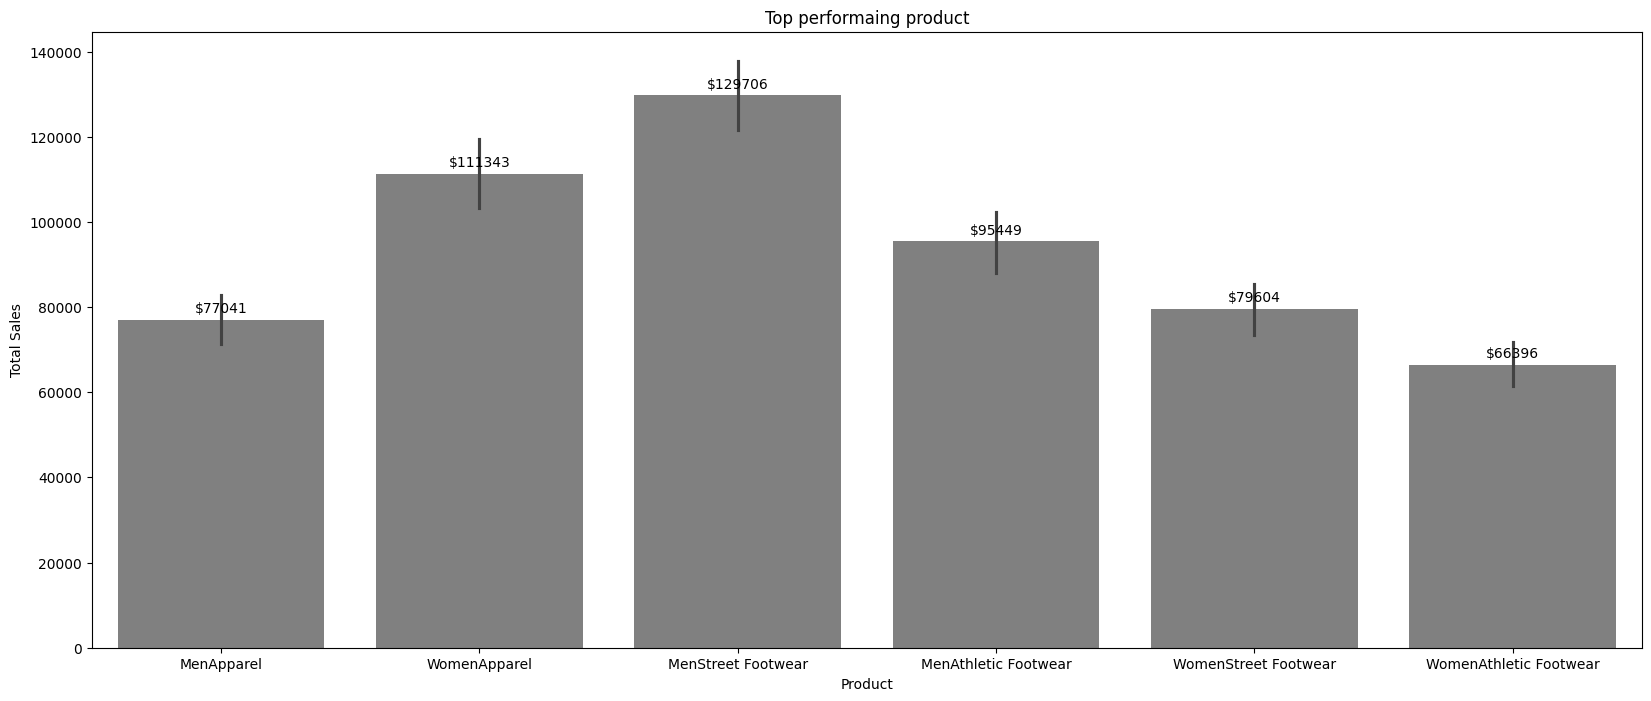

In [123]:
#Top performaing product
plt.figure(figsize=(20,8))
ax=sns.barplot(x=df["Product"],y=df["Total Sales"],color="grey")
ax.bar_label(ax.containers[0],fmt='$%.0f',padding=3)
plt.title("Top performaing product")

[Text(0, 3, '$94203'), Text(0, 3, '$104670'), Text(0, 3, '$80941')]

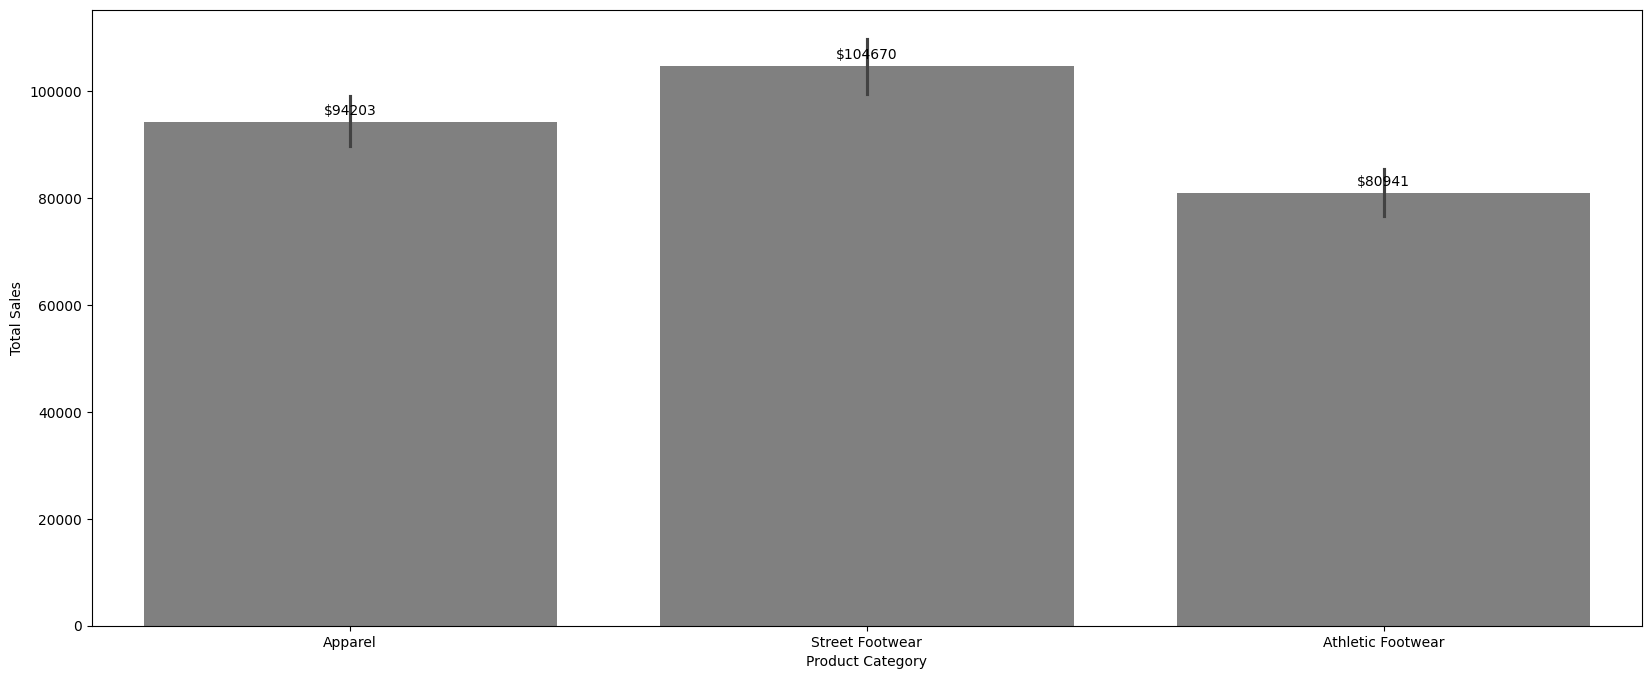

In [124]:
#Top performing product category

plt.figure(figsize=(20,8))
ax=sns.barplot(x=df["Product Category"],y=df["Total Sales"], color='grey')
ax.bar_label(ax.containers[0],fmt='$%.0f',padding=3)

In [125]:
#Total transactions by product category
total_transaction=df.groupby("Product Category")['Transaction Date'].count()
total_transaction

Product Category
Apparel              3214
Athletic Footwear    3216
Street Footwear      3218
Name: Transaction Date, dtype: int64

In [127]:
#Total units sold by gender
Total_unit_sold=df.groupby("Gender Type")["Units Sold"].sum()
Total_unit_sold

Gender Type
Men      1335529
Women    1143332
Name: Units Sold, dtype: int64

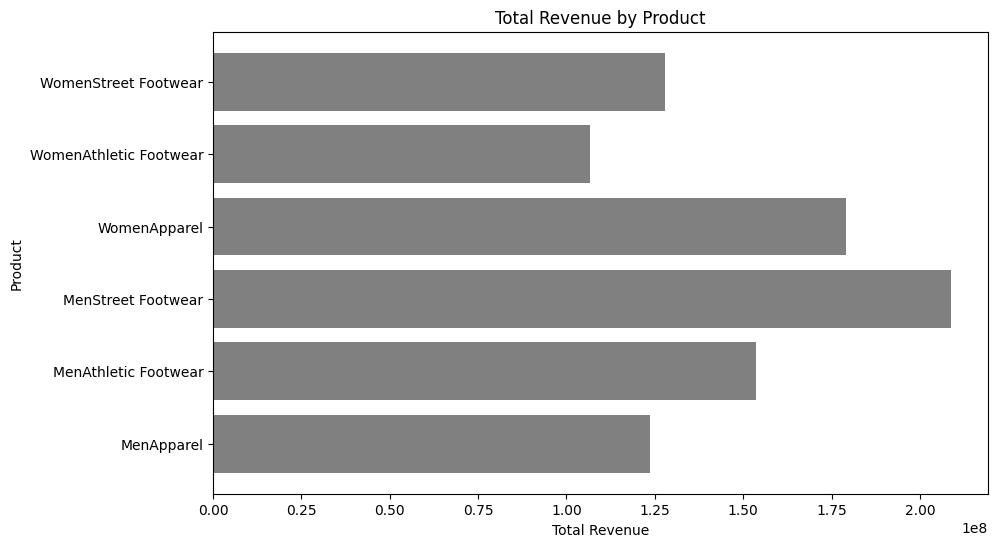

In [ ]:
# Total revenue by product
total_revenue_by_product = df.groupby('Product')['Total Sales'].sum()

plt.figure(figsize=(10,6))
plt.barh(total_revenue_by_product.index,total_revenue_by_product.values,color='grey')

plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.title('Total Revenue by Product')
plt.show()

In [ ]:
# total Retailers
print(f'Total Retailers {df["Retailer"].nunique()}')

Total Retailers 6


In [ ]:
#which retailer most transactions

transactions_by_retailers = df.groupby('Retailer').size().reset_index(name = 'Total Transactions')
print(f'The Retailer with most Transactions is {transactions_by_retailers.iloc[0,0]} with a total of {transactions_by_retailers.iloc[0,1]:,} Transactions')
     

The Retailer with most Transactions is Amazon with a total of 949 Transactions


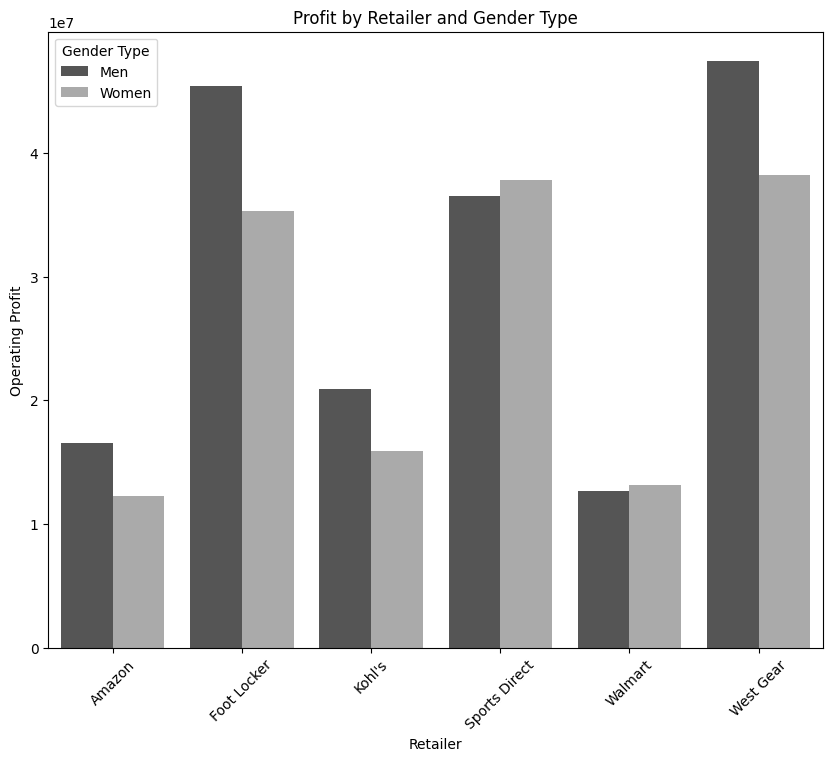

In [ ]:
# Profit by retailer and gender type
profit_by_gender_retailer = (df.groupby(['Retailer', 'Gender Type'])['Operating Profit'].sum().reset_index())

plt.figure(figsize=(10,8))

sns.barplot(
    data=profit_by_gender_retailer,
    x='Retailer',
    y='Operating Profit',
    hue='Gender Type',
    palette='grey'
)

plt.title("Profit by Retailer and Gender Type")
plt.xticks(rotation=45)
plt.show()